# Week 6 Interim Deliverable

In [4]:
import os
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

RANDOM_STATE = 42

print("Libraries loaded successfully.")
print("Random seed:", RANDOM_STATE)


Libraries loaded successfully.
Random seed: 42


In [5]:
from google.colab import drive
drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
DATA_PATH = Path("/content/drive/MyDrive/yaleemmlc_admissionprediction_triage.csv")

df = pd.read_csv(DATA_PATH)

print(f"Loaded {df.shape[0]:,} patient encounters and {df.shape[1]} columns.")
df.head()


Loaded 55,121 patient encounters and 226 columns.


,Unnamed: 0,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,employstatus,insurance_status,disposition,arrivalmode,arrivalmonth,arrivalday,arrivalhour_bin,previousdispo,triage_vital_hr,triage_vital_sbp,triage_vital_dbp,triage_vital_rr,triage_vital_o2,triage_vital_o2_device,triage_vital_temp,triage_glucose,cc_abdominalcramping,cc_abdominaldistention,cc_abdominalpain,cc_abdominalpainpregnant,cc_abnormallab,cc_abscess,cc_addictionproblem,cc_agitation,cc_alcoholintoxication,cc_alcoholproblem,cc_allergicreaction,cc_alteredmentalstatus,cc_animalbite,cc_ankleinjury,...,cc_seizure-newonset,cc_seizure-priorhxof,cc_seizures,cc_shortnessofbreath,cc_shoulderinjury,cc_shoulderpain,cc_sicklecellpain,cc_sinusproblem,cc_skinirritation,cc_skinproblem,cc_sorethroat,cc_stdcheck,cc_strokealert,cc_suicidal,cc_suture/stapleremoval,cc_swallowedforeignbody,cc_syncope,cc_tachycardia,cc_testiclepain,cc_thumbinjury,cc_tickremoval,cc_toeinjury,cc_toepain,cc_trauma,cc_unresponsive,cc_uri,cc_urinaryfrequency,cc_urinaryretention,cc_urinarytractinfection,cc_vaginalbleeding,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
0,7,A,4.0,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,Retired,Medicare,Discharge,Car,March,Saturday,11-14,Admit,88.0,155.0,75.0,17.0,98.0,0.0,97.8,87.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,17,B,2.0,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,Disabled,Medicare,Admit,Walk-in,September,Monday,11-14,Discharge,118.0,105.0,79.0,20.0,98.0,0.0,97.5,113.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,40,A,2.0,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,Full Time,Commercial,Discharge,ambulance,June,Tuesday,15-18,Admit,76.0,116.0,71.0,18.0,99.0,0.0,98.1,108.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,47,A,3.0,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,Full Time,Commercial,Discharge,Car,April,Sunday,23-02,Discharge,106.0,103.0,63.0,16.0,97.0,0.0,98.2,85.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,60,A,2.0,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,Not Employed,Medicaid,Discharge,ambulance,July,Wednesday,23-02,Discharge,84.0,109.0,68.0,18.0,95.0,0.0,97.8,88.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Inspect the Target Variable

The prediction target is `esi`, where ESI 1 is the most urgent and ESI 5 is the least urgent. The class distribution is inspected because triage datasets are usually imbalanced.


In [7]:
TARGET = "esi"

if TARGET not in df.columns:
    raise KeyError(f"Target column '{TARGET}' is not present in the dataset.")

print("ESI class counts:")
display(df[TARGET].value_counts(dropna=False).sort_index())

print("\nESI class percentages:")
display((df[TARGET].value_counts(normalize=True).sort_index() * 100).round(2))


ESI class counts:


,count
esi,
1.0,77
2.0,17924
3.0,27010
4.0,8896
5.0,1214



ESI class percentages:


,proportion
esi,
1.0,0.14
2.0,32.52
3.0,49.00
4.0,16.14
5.0,2.20


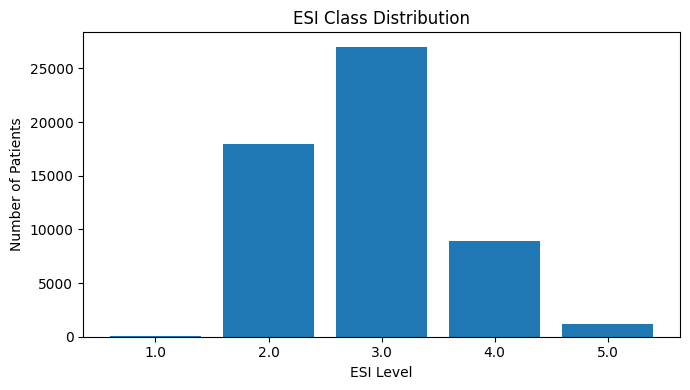

In [8]:
esi_counts = df[TARGET].value_counts().sort_index()

plt.figure(figsize=(7, 4))
plt.bar(esi_counts.index.astype(str), esi_counts.values)
plt.title("ESI Class Distribution")
plt.xlabel("ESI Level")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()


### Observation

If ESI Levels 1 and 5 are rare, overall accuracy may appear acceptable even when the model performs poorly on clinically important minority classes.


## Define Features and Remove Leakage

Only information available at triage should be used as model inputs. Post-triage outcomes such as disposition are excluded because they would cause data leakage.


In [9]:
VITALS = [
    "triage_vital_hr",
    "triage_vital_sbp",
    "triage_vital_dbp",
    "triage_vital_rr",
    "triage_vital_o2",
    "triage_vital_temp",
    "triage_glucose"
]

DEMOGRAPHICS = [
    "age", "gender", "ethnicity", "race", "lang", "religion",
    "maritalstatus", "employstatus", "insurance_status"
]

ADMIN = [
    "dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"
]

LEAKAGE = ["disposition", "previousdispo"]

excluded_columns = [TARGET] + DEMOGRAPHICS + ADMIN + LEAKAGE

FEATURES = [col for col in df.columns if col not in excluded_columns]

print("Number of model features:", len(FEATURES))
print("First 15 features:")
print(FEATURES[:15])


Number of model features: 209
First 15 features:
['Unnamed: 0', 'triage_vital_hr', 'triage_vital_sbp', 'triage_vital_dbp', 'triage_vital_rr', 'triage_vital_o2', 'triage_vital_o2_device', 'triage_vital_temp', 'triage_glucose', 'cc_abdominalcramping', 'cc_abdominaldistention', 'cc_abdominalpain', 'cc_abdominalpainpregnant', 'cc_abnormallab', 'cc_abscess']


## Prepare the Feature Matrix

The models require numeric input. Any unexpected non-numeric values are converted to missing values and then filled using the column median. This is a defensive check; the Week 5 cleaned dataset should already be numeric and complete.


In [10]:
X = df[FEATURES].copy()
y = df[TARGET].copy()

for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors="coerce")

missing_before = int(X.isna().sum().sum())

if missing_before > 0:
    X = X.fillna(X.median(numeric_only=True))

if y.isna().any():
    valid_rows = y.notna()
    X = X.loc[valid_rows].copy()
    y = y.loc[valid_rows].copy()

y = y.astype(int)

print("Missing feature values before defensive filling:", missing_before)
print("Missing feature values after defensive filling:", int(X.isna().sum().sum()))
print("Final feature matrix shape:", X.shape)
print("Final target shape:", y.shape)


Missing feature values before defensive filling: 0
Missing feature values after defensive filling: 0
Final feature matrix shape: (55121, 209)
Final target shape: (55121,)


## Split the Data into Training and Test Sets

An 80/20 stratified split preserves the relative proportion of ESI classes. `random_state=42` makes the split reproducible.


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)


Training set: (44096, 209)
Test set: (11025, 209)


## Train a Stratified Random Baseline

The Dummy Classifier guesses ESI levels according to their frequency in the training data. The real models should outperform this baseline.


In [12]:
dummy = DummyClassifier(
    strategy="stratified",
    random_state=RANDOM_STATE
)

dummy.fit(X_train, y_train)
pred_dummy = dummy.predict(X_test)

print("Dummy baseline accuracy:", round(accuracy_score(y_test, pred_dummy), 4))


Dummy baseline accuracy: 0.3754


## Train Logistic Regression

Logistic Regression requires scaled features because its optimisation is affected by differences in measurement scale.


In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_STATE,
    class_weight="balanced"
)

logreg.fit(X_train_scaled, y_train)
pred_logreg = logreg.predict(X_test_scaled)

print("Logistic Regression accuracy:", round(accuracy_score(y_test, pred_logreg), 4))


Logistic Regression accuracy: 0.5629


## Train the Decision Tree

A maximum depth of 5 is used to reduce overfitting and preserve interpretability.


In [14]:
tree = DecisionTreeClassifier(
    max_depth=5,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

tree.fit(X_train, y_train)
pred_tree = tree.predict(X_test)

print("Decision Tree accuracy:", round(accuracy_score(y_test, pred_tree), 4))


Decision Tree accuracy: 0.2703


## Evaluate Each Model

The classification report provides precision, recall, F1-score, and support for each ESI class.


In [15]:
def print_model_report(name, y_true, y_pred):
    print("=" * 70)
    print(name)
    print("=" * 70)
    print(classification_report(y_true, y_pred, digits=3, zero_division=0))

print_model_report("Dummy Classifier", y_test, pred_dummy)
print_model_report("Logistic Regression", y_test, pred_logreg)
print_model_report("Decision Tree", y_test, pred_tree)


Dummy Classifier
              precision    recall  f1-score   support

           1      0.000     0.000     0.000        16
           2      0.334     0.327     0.331      3585
           3      0.491     0.498     0.494      5402
           4      0.147     0.148     0.147      1779
           5      0.049     0.045     0.047       243

    accuracy                          0.375     11025
   macro avg      0.204     0.204     0.204     11025
weighted avg      0.374     0.375     0.375     11025

Logistic Regression
              precision    recall  f1-score   support

           1      0.017     0.625     0.032        16
           2      0.656     0.601     0.627      3585
           3      0.762     0.500     0.604      5402
           4      0.490     0.657     0.561      1779
           5      0.141     0.700     0.234       243

    accuracy                          0.563     11025
   macro avg      0.413     0.617     0.412     11025
weighted avg      0.669     0.563     0.

## Confusion Matrices

The most serious failure is an ESI Level 1 patient being predicted as a less urgent class.


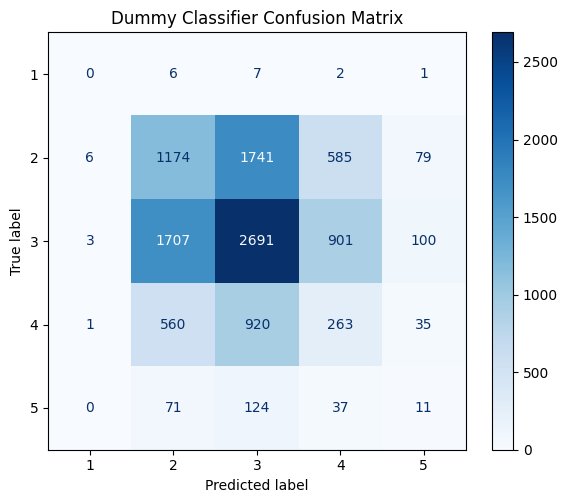

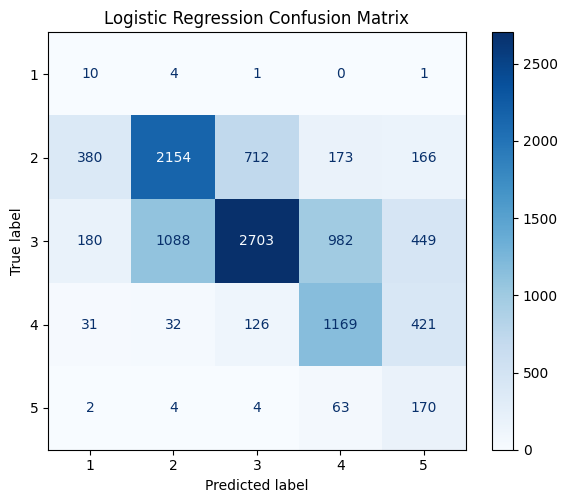

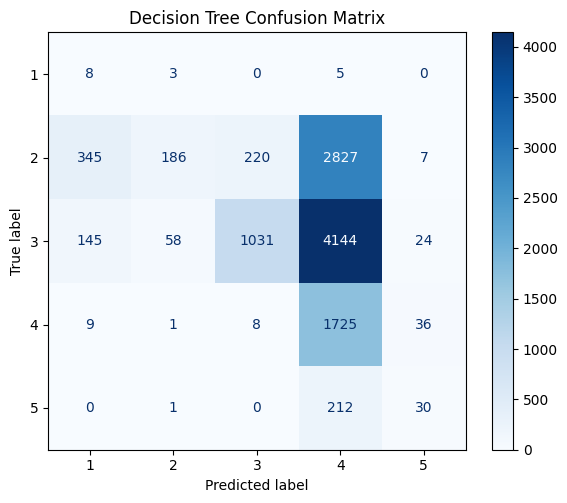

In [16]:
os.makedirs("figs", exist_ok=True)

models_and_predictions = {
    "Dummy Classifier": pred_dummy,
    "Logistic Regression": pred_logreg,
    "Decision Tree": pred_tree
}

for model_name, predictions in models_and_predictions.items():
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions,
        labels=sorted(y.unique()),
        cmap="Blues",
        values_format="d",
        ax=ax
    )
    ax.set_title(f"{model_name} Confusion Matrix")
    plt.tight_layout()

    safe_name = model_name.lower().replace(" ", "_")
    plt.savefig(f"figs/{safe_name}_confusion_matrix.png", dpi=150)
    plt.show()


## Compare Overall Model Performance

Macro F1 gives equal importance to every ESI class. Weighted F1 gives more influence to common classes. A large gap between them suggests stronger performance on common classes than on rare classes.


In [17]:
def model_metrics(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Weighted F1": f1_score(y_true, y_pred, average="weighted", zero_division=0)
    }

comparison = pd.DataFrame([
    model_metrics("Dummy Classifier", y_test, pred_dummy),
    model_metrics("Logistic Regression", y_test, pred_logreg),
    model_metrics("Decision Tree", y_test, pred_tree)
])

numeric_cols = comparison.columns.drop("Model")
comparison[numeric_cols] = comparison[numeric_cols].round(3)

comparison


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Dummy Classifier,0.375,0.204,0.204,0.204,0.375
1,Logistic Regression,0.563,0.413,0.617,0.412,0.596
2,Decision Tree,0.270,0.417,0.367,0.187,0.239


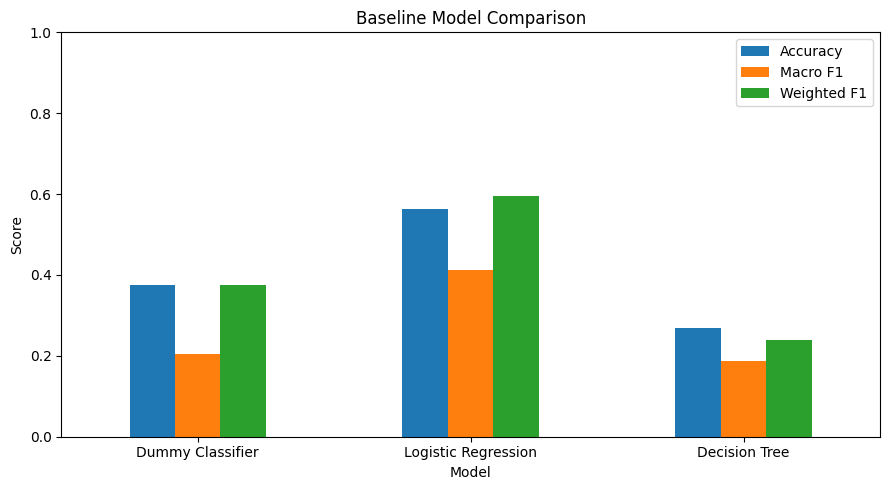

In [18]:
comparison_plot = comparison.set_index("Model")[["Accuracy", "Macro F1", "Weighted F1"]]

comparison_plot.plot(kind="bar", figsize=(9, 5))
plt.title("Baseline Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("figs/model_comparison.png", dpi=150)
plt.show()


##  ESI Level 1 Recall

Recall for ESI Level 1 answers: of all patients who truly required immediate life-saving intervention, what proportion did the model correctly identify as ESI 1?


In [19]:
def class_recall(y_true, y_pred, class_label=1):
    return recall_score(
        y_true,
        y_pred,
        labels=[class_label],
        average=None,
        zero_division=0
    )[0]

esi1_recall_table = pd.DataFrame({
    "Model": ["Dummy Classifier", "Logistic Regression", "Decision Tree"],
    "ESI 1 Recall": [
        class_recall(y_test, pred_dummy, 1),
        class_recall(y_test, pred_logreg, 1),
        class_recall(y_test, pred_tree, 1)
    ]
})

esi1_recall_table["ESI 1 Recall"] = esi1_recall_table["ESI 1 Recall"].round(3)
esi1_recall_table


,Model,ESI 1 Recall
0,Dummy Classifier,0.000
1,Logistic Regression,0.625
2,Decision Tree,0.500


## Primary Metric Justification

**Primary metric: Recall for ESI Level 1**

Recall for ESI Level 1 is prioritised because the most dangerous error is failing to identify a patient who requires immediate life-saving intervention. If a true ESI 1 patient is assigned a lower-priority category, treatment may be delayed and the patient's condition could rapidly worsen. By contrast, assigning a stable patient to a higher-acuity category may increase resource use, but it is generally less harmful than under-triaging a critically ill patient. Overall accuracy is not sufficient because ESI 1 patients are relatively rare, allowing a model to appear accurate while still missing the sickest patients.


## Failure-Mode Reflection

The failure mode of greatest concern is under-triage, especially when an ESI Level 1 patient is predicted as ESI 2, 3, 4, or 5. In practice, this could delay resuscitation, monitoring, or senior clinical review. The confusion matrices should therefore be examined for how often true ESI 1 cases are placed outside the ESI 1 column.


##  Save the Models and Outputs


In [20]:
os.makedirs("models", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

joblib.dump(dummy, "models/dummy_classifier.joblib")
joblib.dump(logreg, "models/logistic_regression.joblib")
joblib.dump(tree, "models/decision_tree.joblib")
joblib.dump(scaler, "models/standard_scaler.joblib")
joblib.dump(FEATURES, "models/feature_list.joblib")

comparison.to_csv("outputs/model_comparison.csv", index=False)
esi1_recall_table.to_csv("outputs/esi1_recall_comparison.csv", index=False)

print("Models and evaluation tables saved successfully.")


Models and evaluation tables saved successfully.
